In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed

In [4]:
data_folder = r"C:\Users\erik-\OneDrive\Documentos\GitHub\DETECCION-DE-ANOMALIAS\processed_data"

files = [
    "Monday-WorkingHours.pcap_ISCX_processed.csv",
    "Tuesday-WorkingHours.pcap_ISCX_processed.csv",
    "Wednesday-workingHours.pcap_ISCX_processed.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX_processed.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX_processed.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX_processed.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX_processed.csv",
    "Friday-WorkingHours-Afternoon-DDoS.pcap_ISCX_processed.csv"
]

# Features seleccionadas
selected_features = [
    'Flow Duration',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Fwd Packets/s',
    'Bwd Packets/s',
    'Packet Length Mean',
    'flow_count'
]


In [6]:
train_path = os.path.join(data_folder, files[0])
train_data = pd.read_csv(train_path)

X_train = train_data[selected_features]
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

test_data = pd.concat(
    [pd.read_csv(os.path.join(data_folder, f)) for f in files[1:]],
    ignore_index=True
)

X_test = test_data[selected_features]
X_test_scaled = scaler.transform(X_test)

In [7]:
file_paths = [os.path.join(data_folder, f) for f in files]

***MODELADO LSTM***

In [8]:
def create_sequences(X, time_steps=60):
    Xs = []
    
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
    
    return np.array(Xs)

time_steps = 60 

X_train_seq = create_sequences(X_train_scaled, time_steps)
X_test_seq = create_sequences(X_test_scaled, time_steps)

In [10]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense

n_features = X_train_seq.shape[2]

# ENCODER
inputs = Input(shape=(time_steps, n_features))

encoded = LSTM(64, activation='relu', return_sequences=False)(inputs)

# bottleneck
encoded = RepeatVector(time_steps)(encoded)

# DECODER
decoded = LSTM(64, activation='relu', return_sequences=True)(encoded)

decoded = TimeDistributed(Dense(n_features))(decoded)


# MODEL
model = Model(inputs, decoded)
model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 11)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 60, 11)         │           715 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,195 (207.79 KB)

 Trainable params: 53,195 (207.79 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    X_train_seq,
    X_train_seq,
    epochs=3,
    batch_size=64,
    validation_split=0.1,
    shuffle=True
)

Epoch 1/3
7452/7452 ━━━━━━━━━━━━━━━━━━━━ 346s 46ms/step - loss: 0.0046 - val_loss: 9.9554e-04
Epoch 2/3
7452/7452 ━━━━━━━━━━━━━━━━━━━━ 897s 120ms/step - loss: 0.0037 - val_loss: 9.4119e-04
Epoch 3/3
7452/7452 ━━━━━━━━━━━━━━━━━━━━ 869s 117ms/step - loss: 0.0034 - val_loss: 7.1390e-04


In [ ]:
test_file = "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX_processed.csv"

test_path = os.path.join(data_folder, test_file)
test_data = pd.read_csv(test_path)
X_test = test_data[selected_features].values
X_test = np.nan_to_num(X_test)
X_test_scaled = scaler.transform(X_test)

def create_sequences(X, time_steps):
    for i in range(len(X) - time_steps):
        yield X[i:i+time_steps]


train_preds = []
train_seqs = []

train_generator = create_sequences(X_train_scaled, time_steps)
train_steps = len(X_train_scaled) - time_steps

for seq in tqdm(train_generator, total=train_steps, desc="Processing TRAIN"):
    seq = np.array(seq)[None, :, :]

    pred = model.predict(seq, verbose=0)

    train_preds.append(pred[0])
    train_seqs.append(seq[0])

X_train_pred = np.array(train_preds)
X_train_seq = np.array(train_seqs)

train_mse = np.mean(
    np.power(X_train_seq - X_train_pred, 2),
    axis=(1,2)
)

threshold = np.mean(train_mse) + 3 * np.std(train_mse)

print("Threshold (TRAIN):", threshold)

preds = []
seqs = []

generator = create_sequences(X_test_scaled, time_steps)
total_steps = len(X_test_scaled) - time_steps

for seq in tqdm(generator, total=total_steps, desc="Evaluating TEST"):
    seq = np.array(seq)[None, :, :]

    pred = model.predict(seq, verbose=0)

    preds.append(pred[0])
    seqs.append(seq[0])

X_pred = np.array(preds)
X_test_seq = np.array(seqs)

mse = np.mean(
    np.power(X_test_seq - X_pred, 2),
    axis=(1,2)
)

y_pred = (mse > threshold).astype(int)

y_true = test_data['Label'].iloc[
    time_steps:time_steps + len(y_pred)
].apply(lambda x: 0 if x == "BENIGN" else 1).values


C:\Users\erik-\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
Evaluating: 100%|██████████| 286407/286407 [7:44:31<00:00, 10.28it/s]   


Threshold: 0.004120798154023726


***Métricas y gráficas***

In [22]:
print("\nClassification Report:")
print(classification_report(y_true, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.89      0.57    127477
           1       0.03      0.00      0.00    158930

    accuracy                           0.40    286407
   macro avg       0.22      0.45      0.29    286407
weighted avg       0.20      0.40      0.26    286407



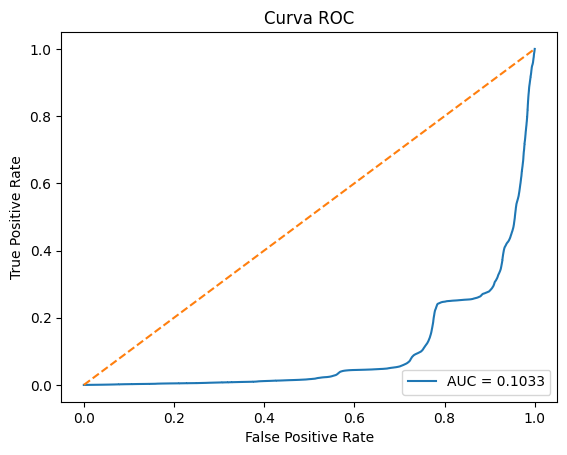

In [21]:
fpr, tpr, thresholds = roc_curve(y_true, mse)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')  # línea diagonal

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()

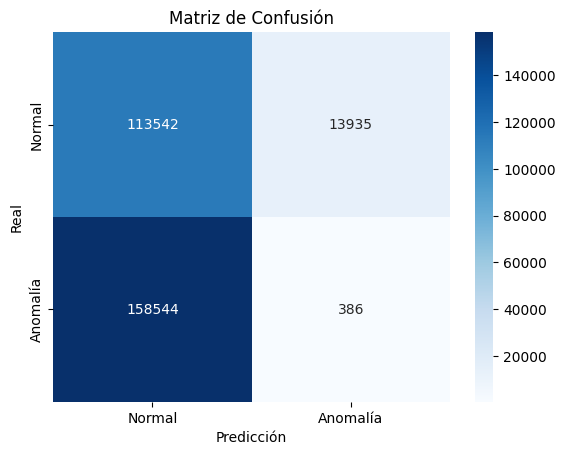

In [20]:
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomalía'],
            yticklabels=['Normal', 'Anomalía'])

plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

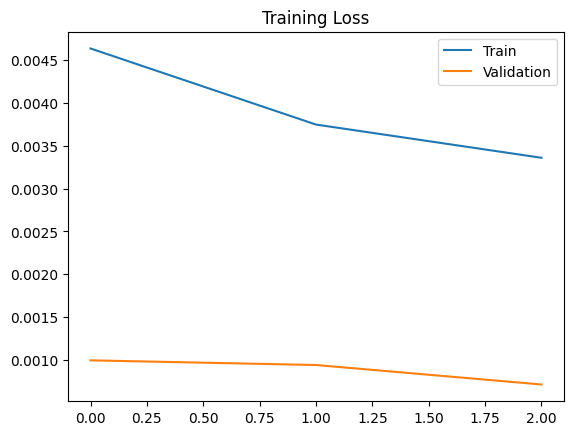

In [15]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Training Loss")
plt.legend()
plt.show()

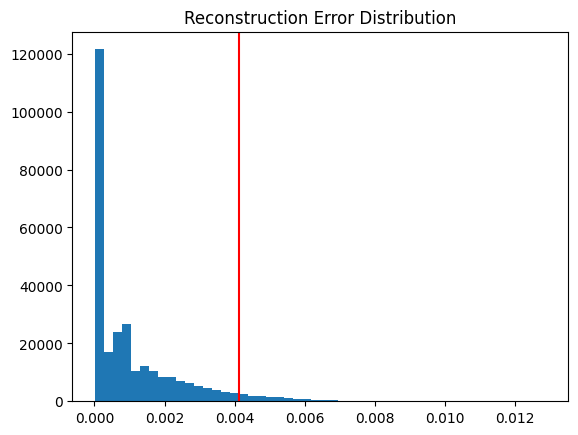

In [16]:
plt.hist(mse, bins=50)
plt.axvline(threshold, color='r')
plt.title("Reconstruction Error Distribution")
plt.show()